# Visualize All Runs for a Given Configuration

This notebook allows you to visualize all 30 runs for a specific parameter configuration (strategy set, N, K, mu) in a 5x6 grid layout.

This helps you:
- Understand equilibrium diversity visually
- Verify if equilibrium classification is accurate
- Compare price trajectories across different runs

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

# Add project root to sys.path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Setup Plotting Style
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (20, 16)

## Helper Functions

In [2]:
def find_experiment_dir(strats, mu, k):
    """
    Find the experiment directory matching the given parameters.
    
    Parameters:
    -----------
    strats : int
        Number of strategies (3 or 4)
    mu : float
        Learning rate parameter
    k : int
        K parameter
    
    Returns:
    --------
    Path or None
        The experiment directory path if found, None otherwise
    """
    results_dir = project_root / "data" / "results"
    
    # Construct the expected directory name pattern
    strat_str = f"{strats}strats"
    mu_str = f"mu{mu}"
    k_str = f"k{k}"
    
    # Search for matching directory
    for exp_dir in results_dir.iterdir():
        if not exp_dir.is_dir():
            continue
        
        dir_name = exp_dir.name
        if strat_str in dir_name and mu_str in dir_name and k_str in dir_name:
            return exp_dir
    
    return None


def load_all_runs(strats, N, k, mu):
    """
    Load all parquet files for a given configuration.
    
    Parameters:
    -----------
    strats : int
        Number of strategies (3 or 4)
    N : int
        Number of sellers
    k : int
        K parameter
    mu : float
        Learning rate parameter
    
    Returns:
    --------
    list of tuples
        List of (run_id, DataFrame) tuples
    """
    exp_dir = find_experiment_dir(strats, mu, k)
    
    if exp_dir is None:
        print(f"No experiment found for: {strats}strats, mu={mu}, k={k}")
        return []
    
    n_dir = exp_dir / f"N_{N}"
    
    if not n_dir.exists():
        print(f"No N_{N} directory found in {exp_dir.name}")
        return []
    
    # Load all parquet files
    parquet_files = sorted(list(n_dir.glob("run_*.parquet")))
    
    if not parquet_files:
        print(f"No parquet files found in {n_dir}")
        return []
    
    print(f"Found {len(parquet_files)} runs in {exp_dir.name}/N_{N}")
    
    runs = []
    for pf in parquet_files:
        # Extract run number from filename (e.g., run_0.parquet -> 0)
        run_id = int(pf.stem.split('_')[1])
        df = pd.read_parquet(pf)
        runs.append((run_id, df))
    
    # Sort by run_id
    runs.sort(key=lambda x: x[0])
    
    return runs

## Main Visualization Function

In [3]:
def plot_all_runs_grid(strats, N, k, mu, max_steps=200, figsize=(24, 20)):
    """
    Plot all runs for a given configuration in a 5x6 grid.
    
    Parameters:
    -----------
    strats : int
        Number of strategies (3 or 4)
    N : int
        Number of sellers
    k : int
        K parameter
    mu : float
        Learning rate parameter
    max_steps : int, optional
        Maximum number of steps to display (default: 200)
    figsize : tuple, optional
        Figure size (default: (24, 20))
    """
    # Load all runs
    runs = load_all_runs(strats, N, k, mu)
    
    if not runs:
        print("No data to plot.")
        return
    
    # Create 5x6 grid
    fig, axes = plt.subplots(5, 6, figsize=figsize)
    axes = axes.flatten()
    
    # Plot each run
    for idx, (run_id, df) in enumerate(runs):
        if idx >= 30:  # Only plot first 30 runs
            break
        
        ax = axes[idx]
        
        # Slice data to max_steps
        plot_data = df.iloc[:max_steps]
        
        # Find all price columns (p_0, p_1, ...)
        p_cols = sorted([c for c in plot_data.columns if c.startswith('p_')])
        
        # Plot each seller's price
        for col in p_cols:
            ax.plot(plot_data['t_global'], plot_data[col], 
                   linewidth=1.5, alpha=0.7)
        
        ax.set_title(f"Run {run_id}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Time Step", fontsize=8)
        ax.set_ylabel("Price", fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots if less than 30 runs
    for idx in range(len(runs), 30):
        axes[idx].axis('off')
    
    # Overall title
    fig.suptitle(
        f"All Runs: {strats} Strategies | N={N} Sellers | K={k} | mu={mu}\n"
        f"(Showing first {max_steps} steps per run)",
        fontsize=16, fontweight='bold', y=0.995
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()


## Examples

Use the function below to visualize all runs for specific configurations.

Found 30 runs in scan_3strats_mu0.01_k30/N_7


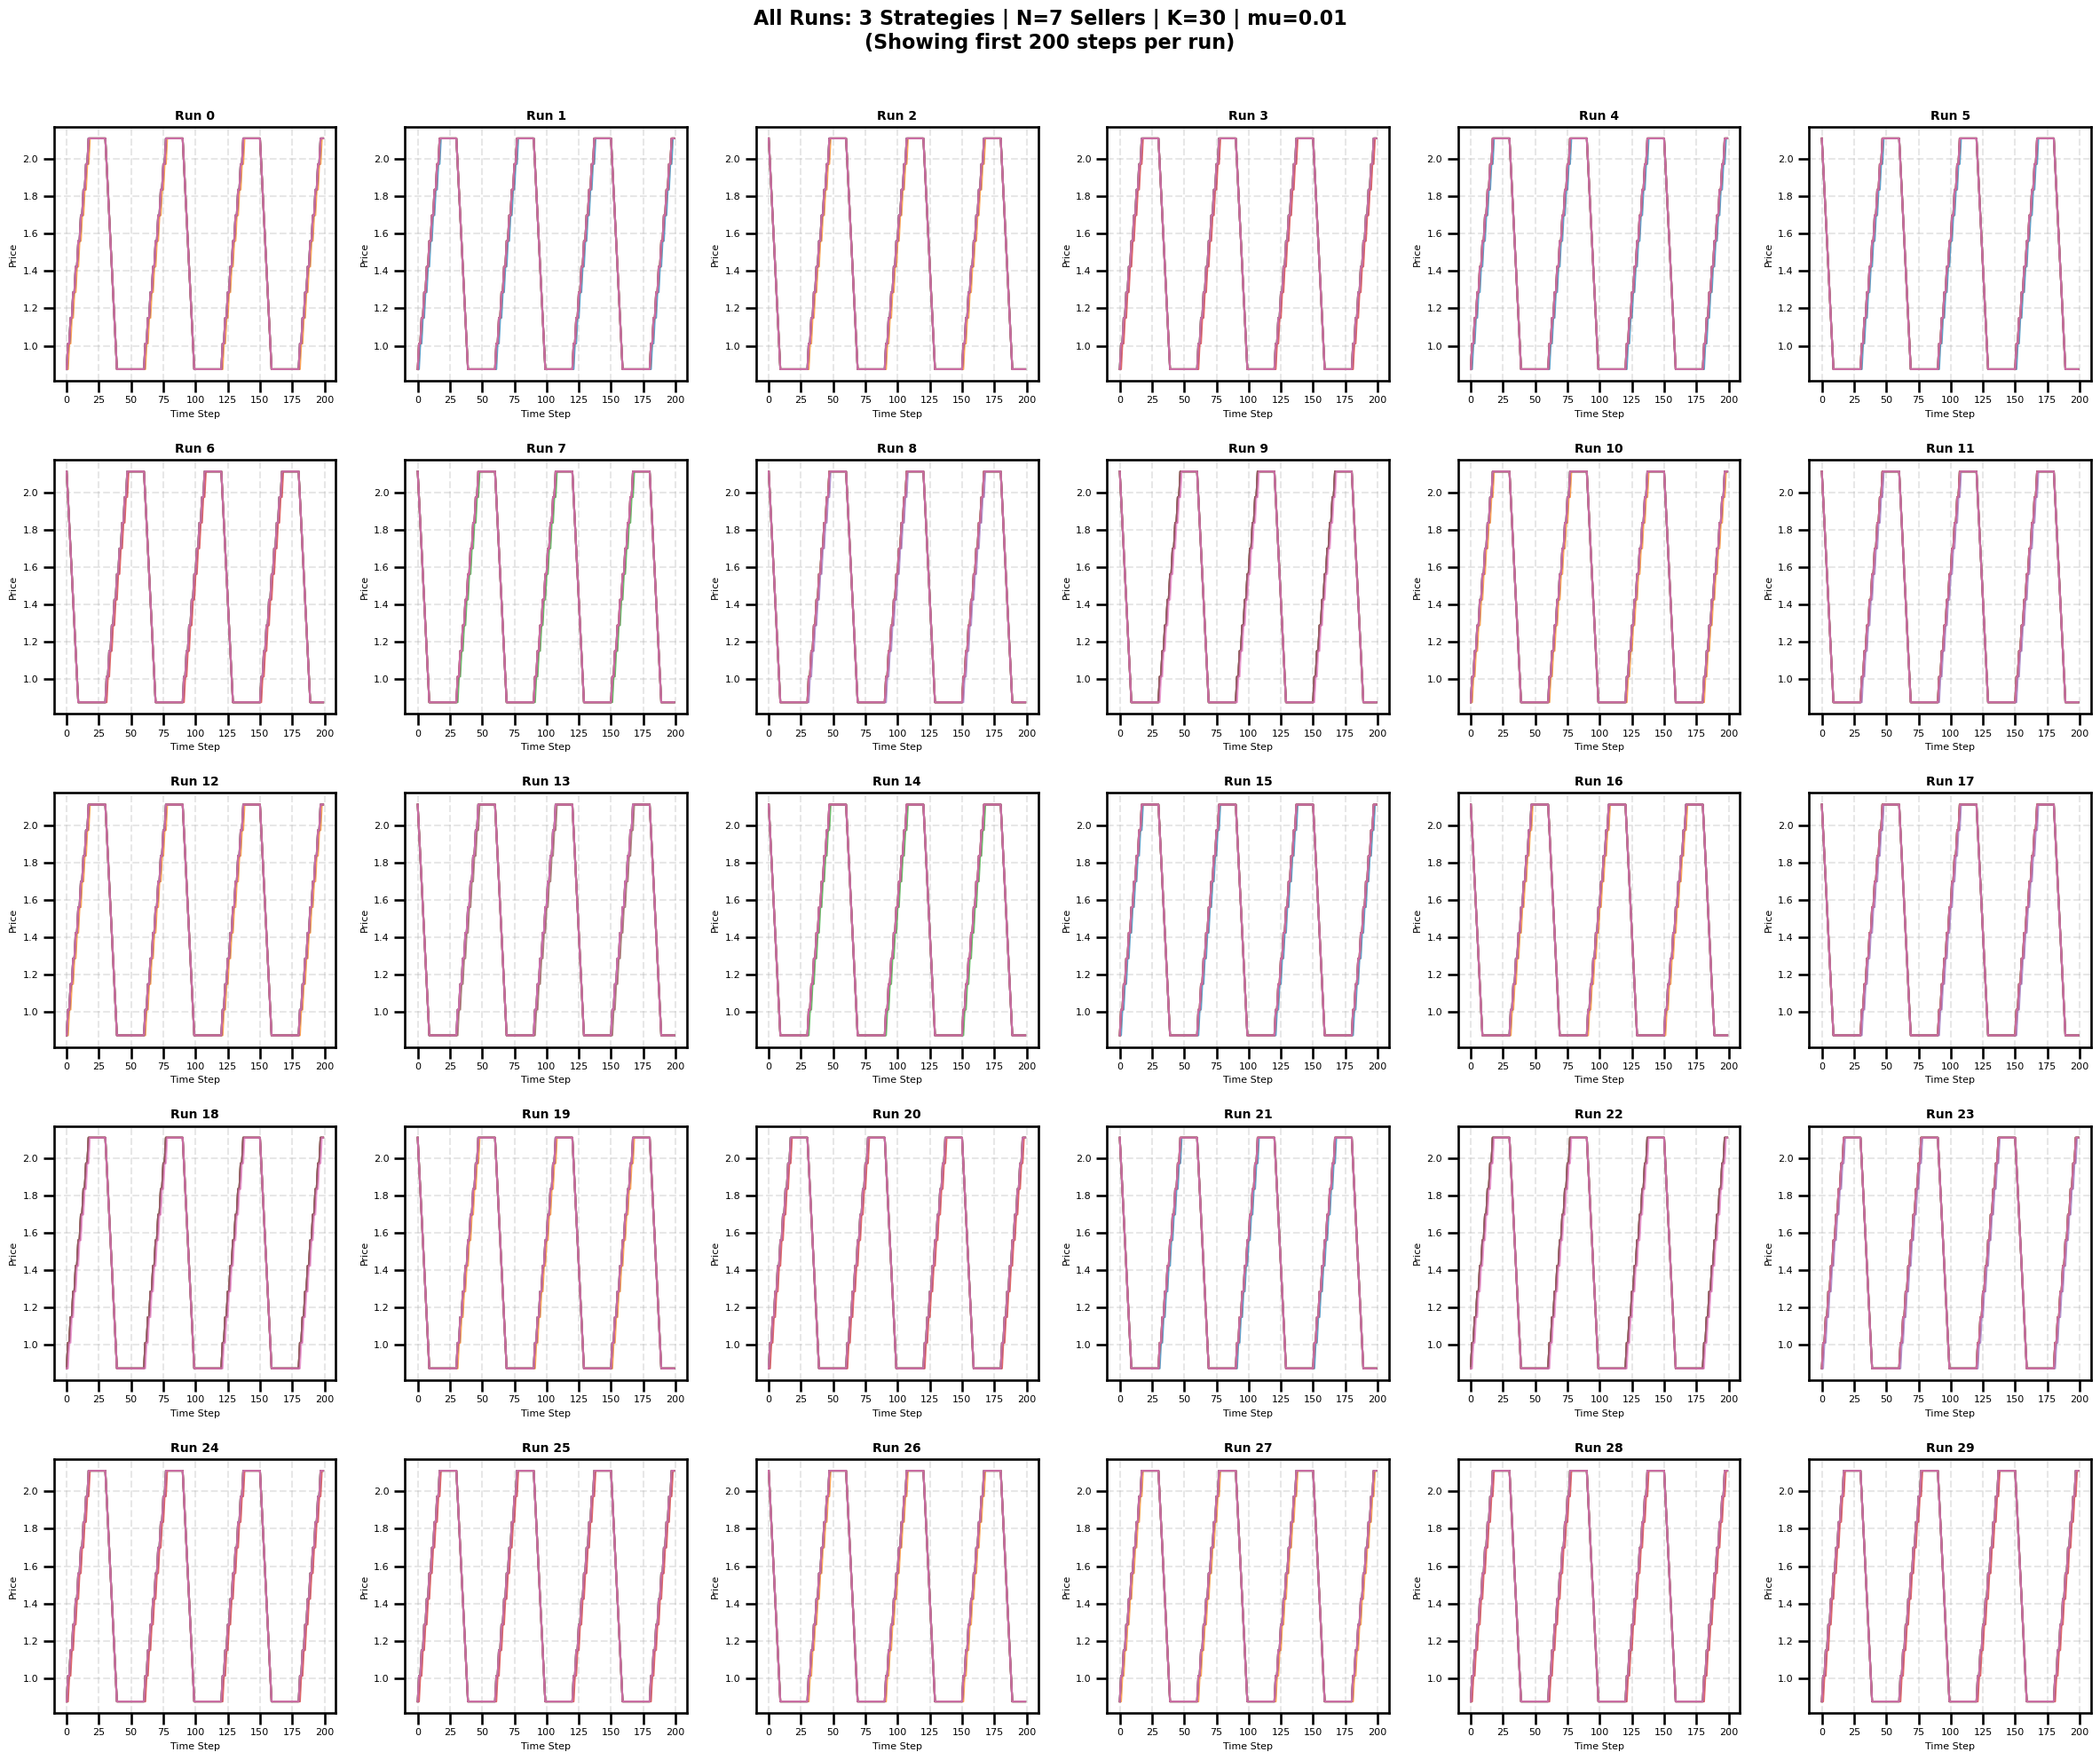

In [4]:
# Example 1: 3 strategies, N=7, K=30, mu=0.01
plot_all_runs_grid(strats=3, N=7, k=30, mu=0.01, max_steps=200)

Found 30 runs in scan_4strats_mu0.13_k35/N_2


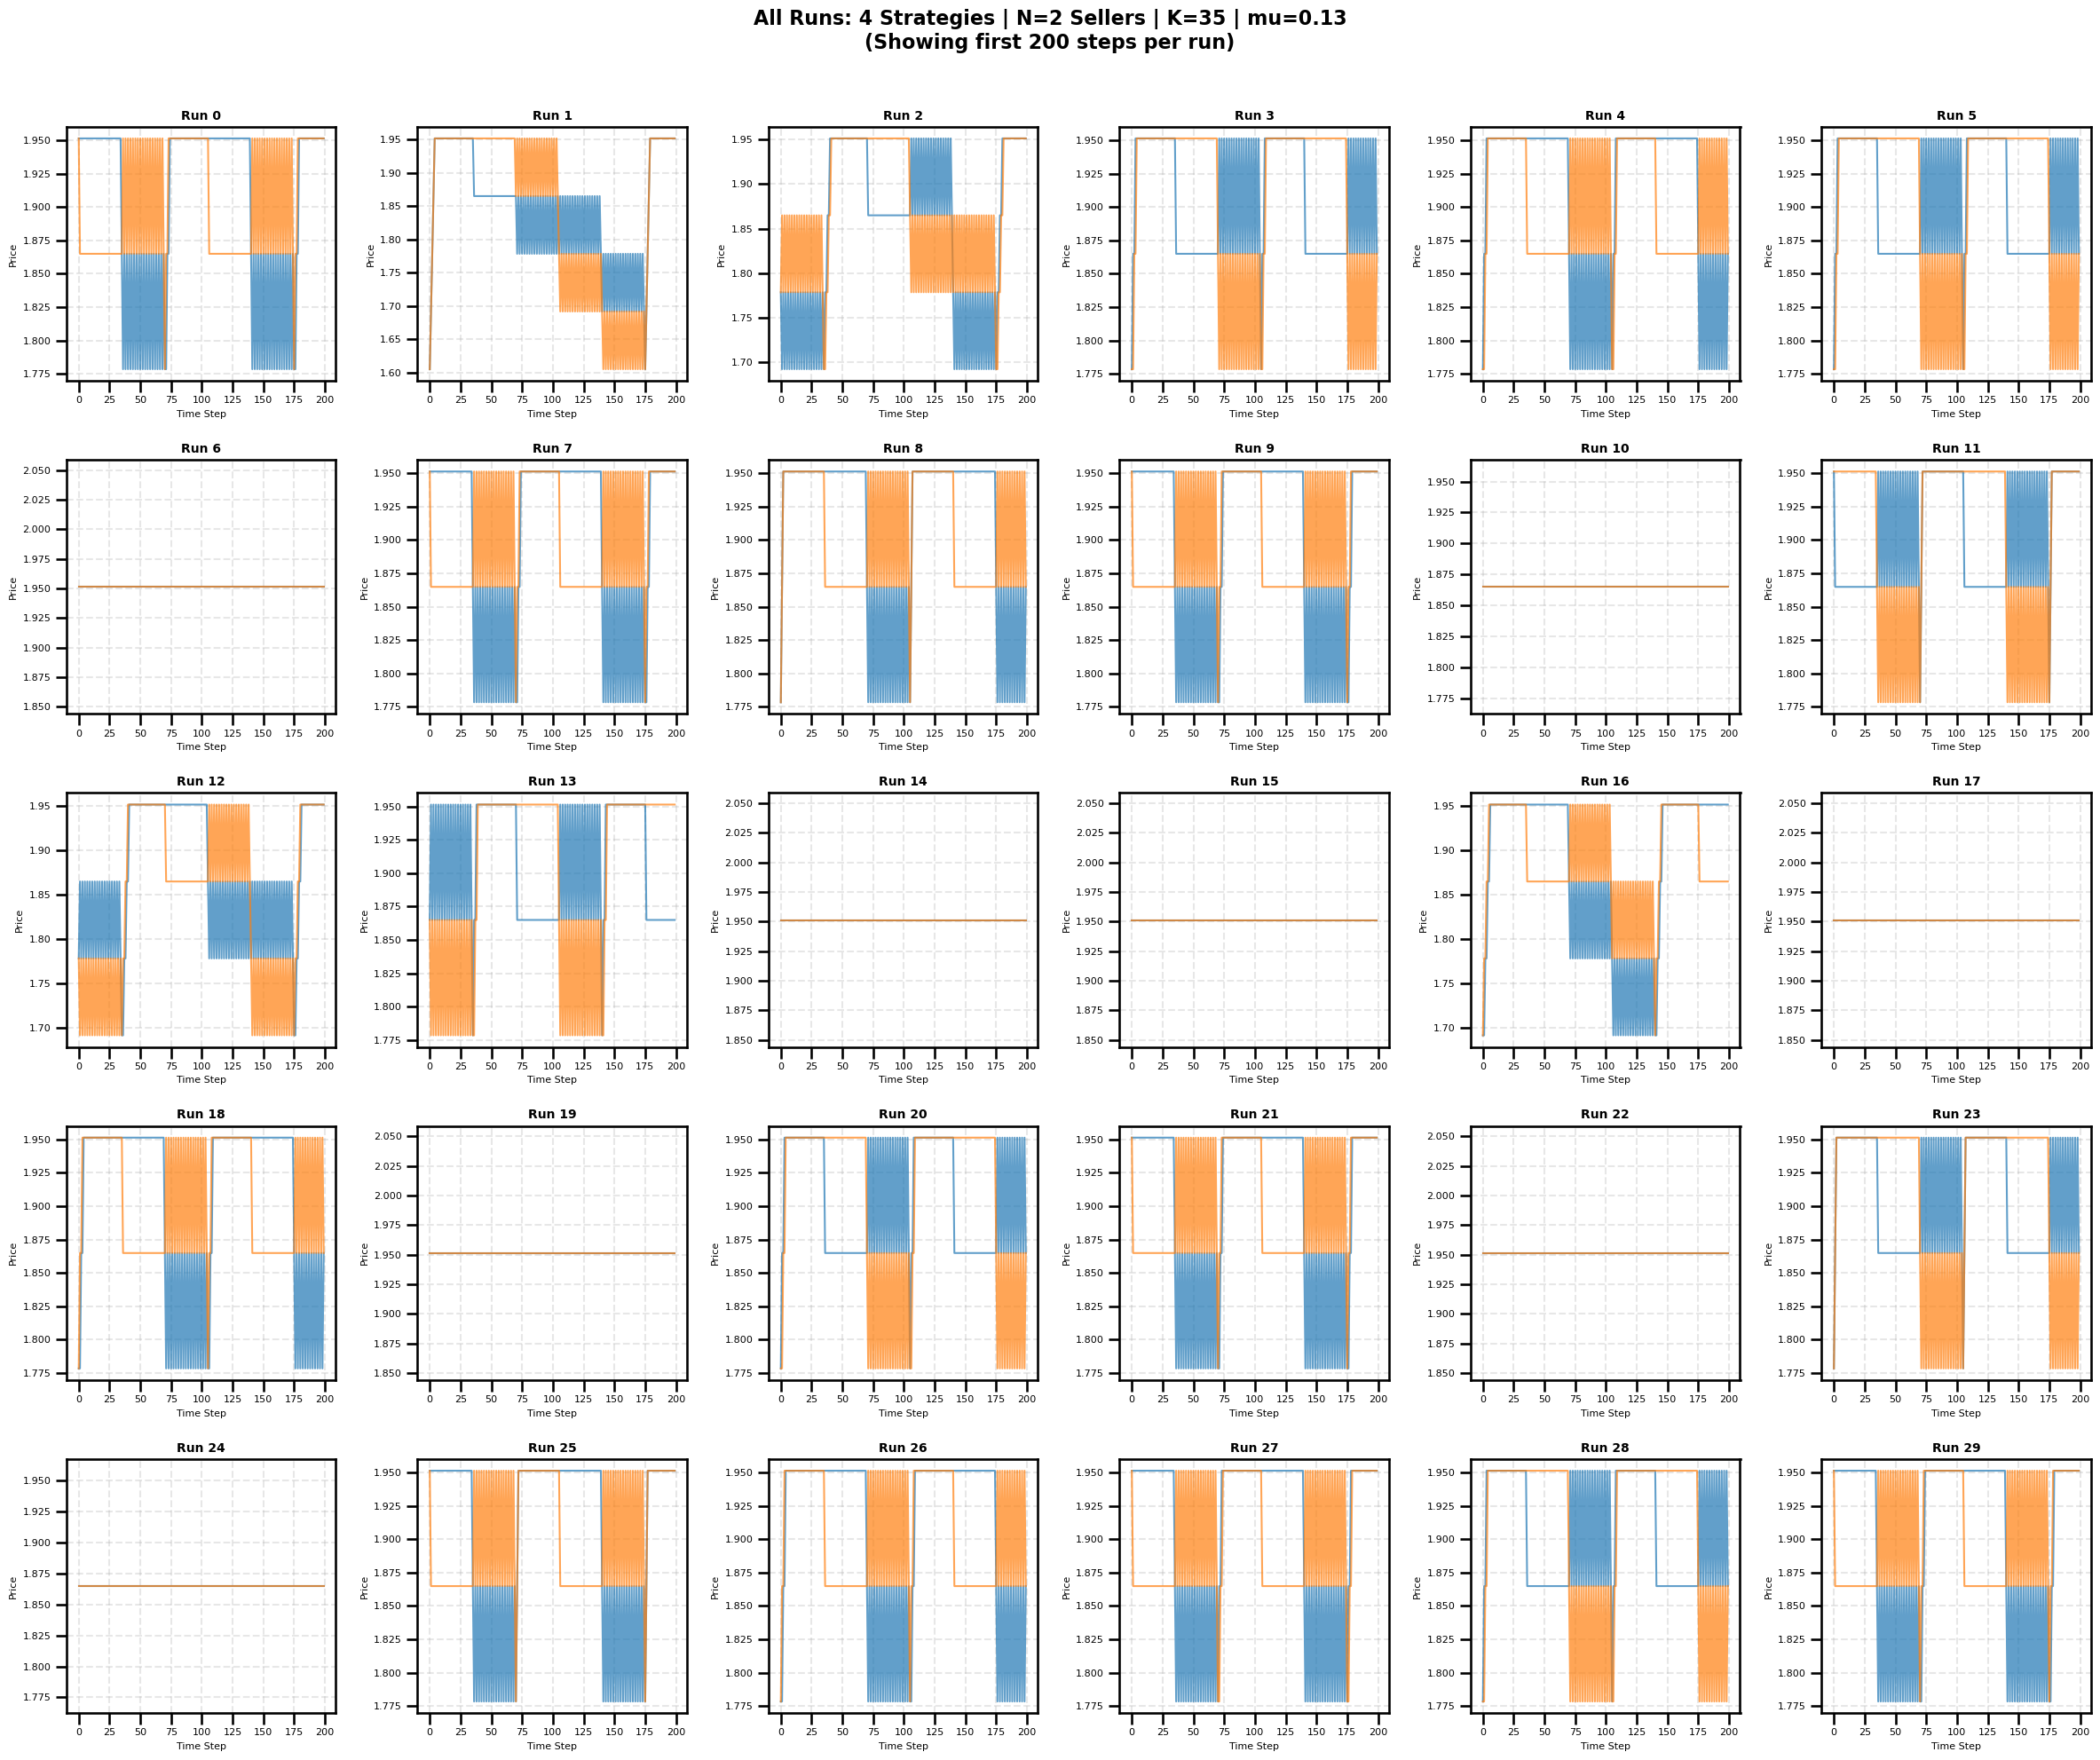

In [5]:
# Example 2: 4 strategies, N=2, K=35, mu=0.13
plot_all_runs_grid(strats=4, N=2, k=35, mu=0.13, max_steps=200)

Found 30 runs in scan_3strats_mu0.01_k25/N_7


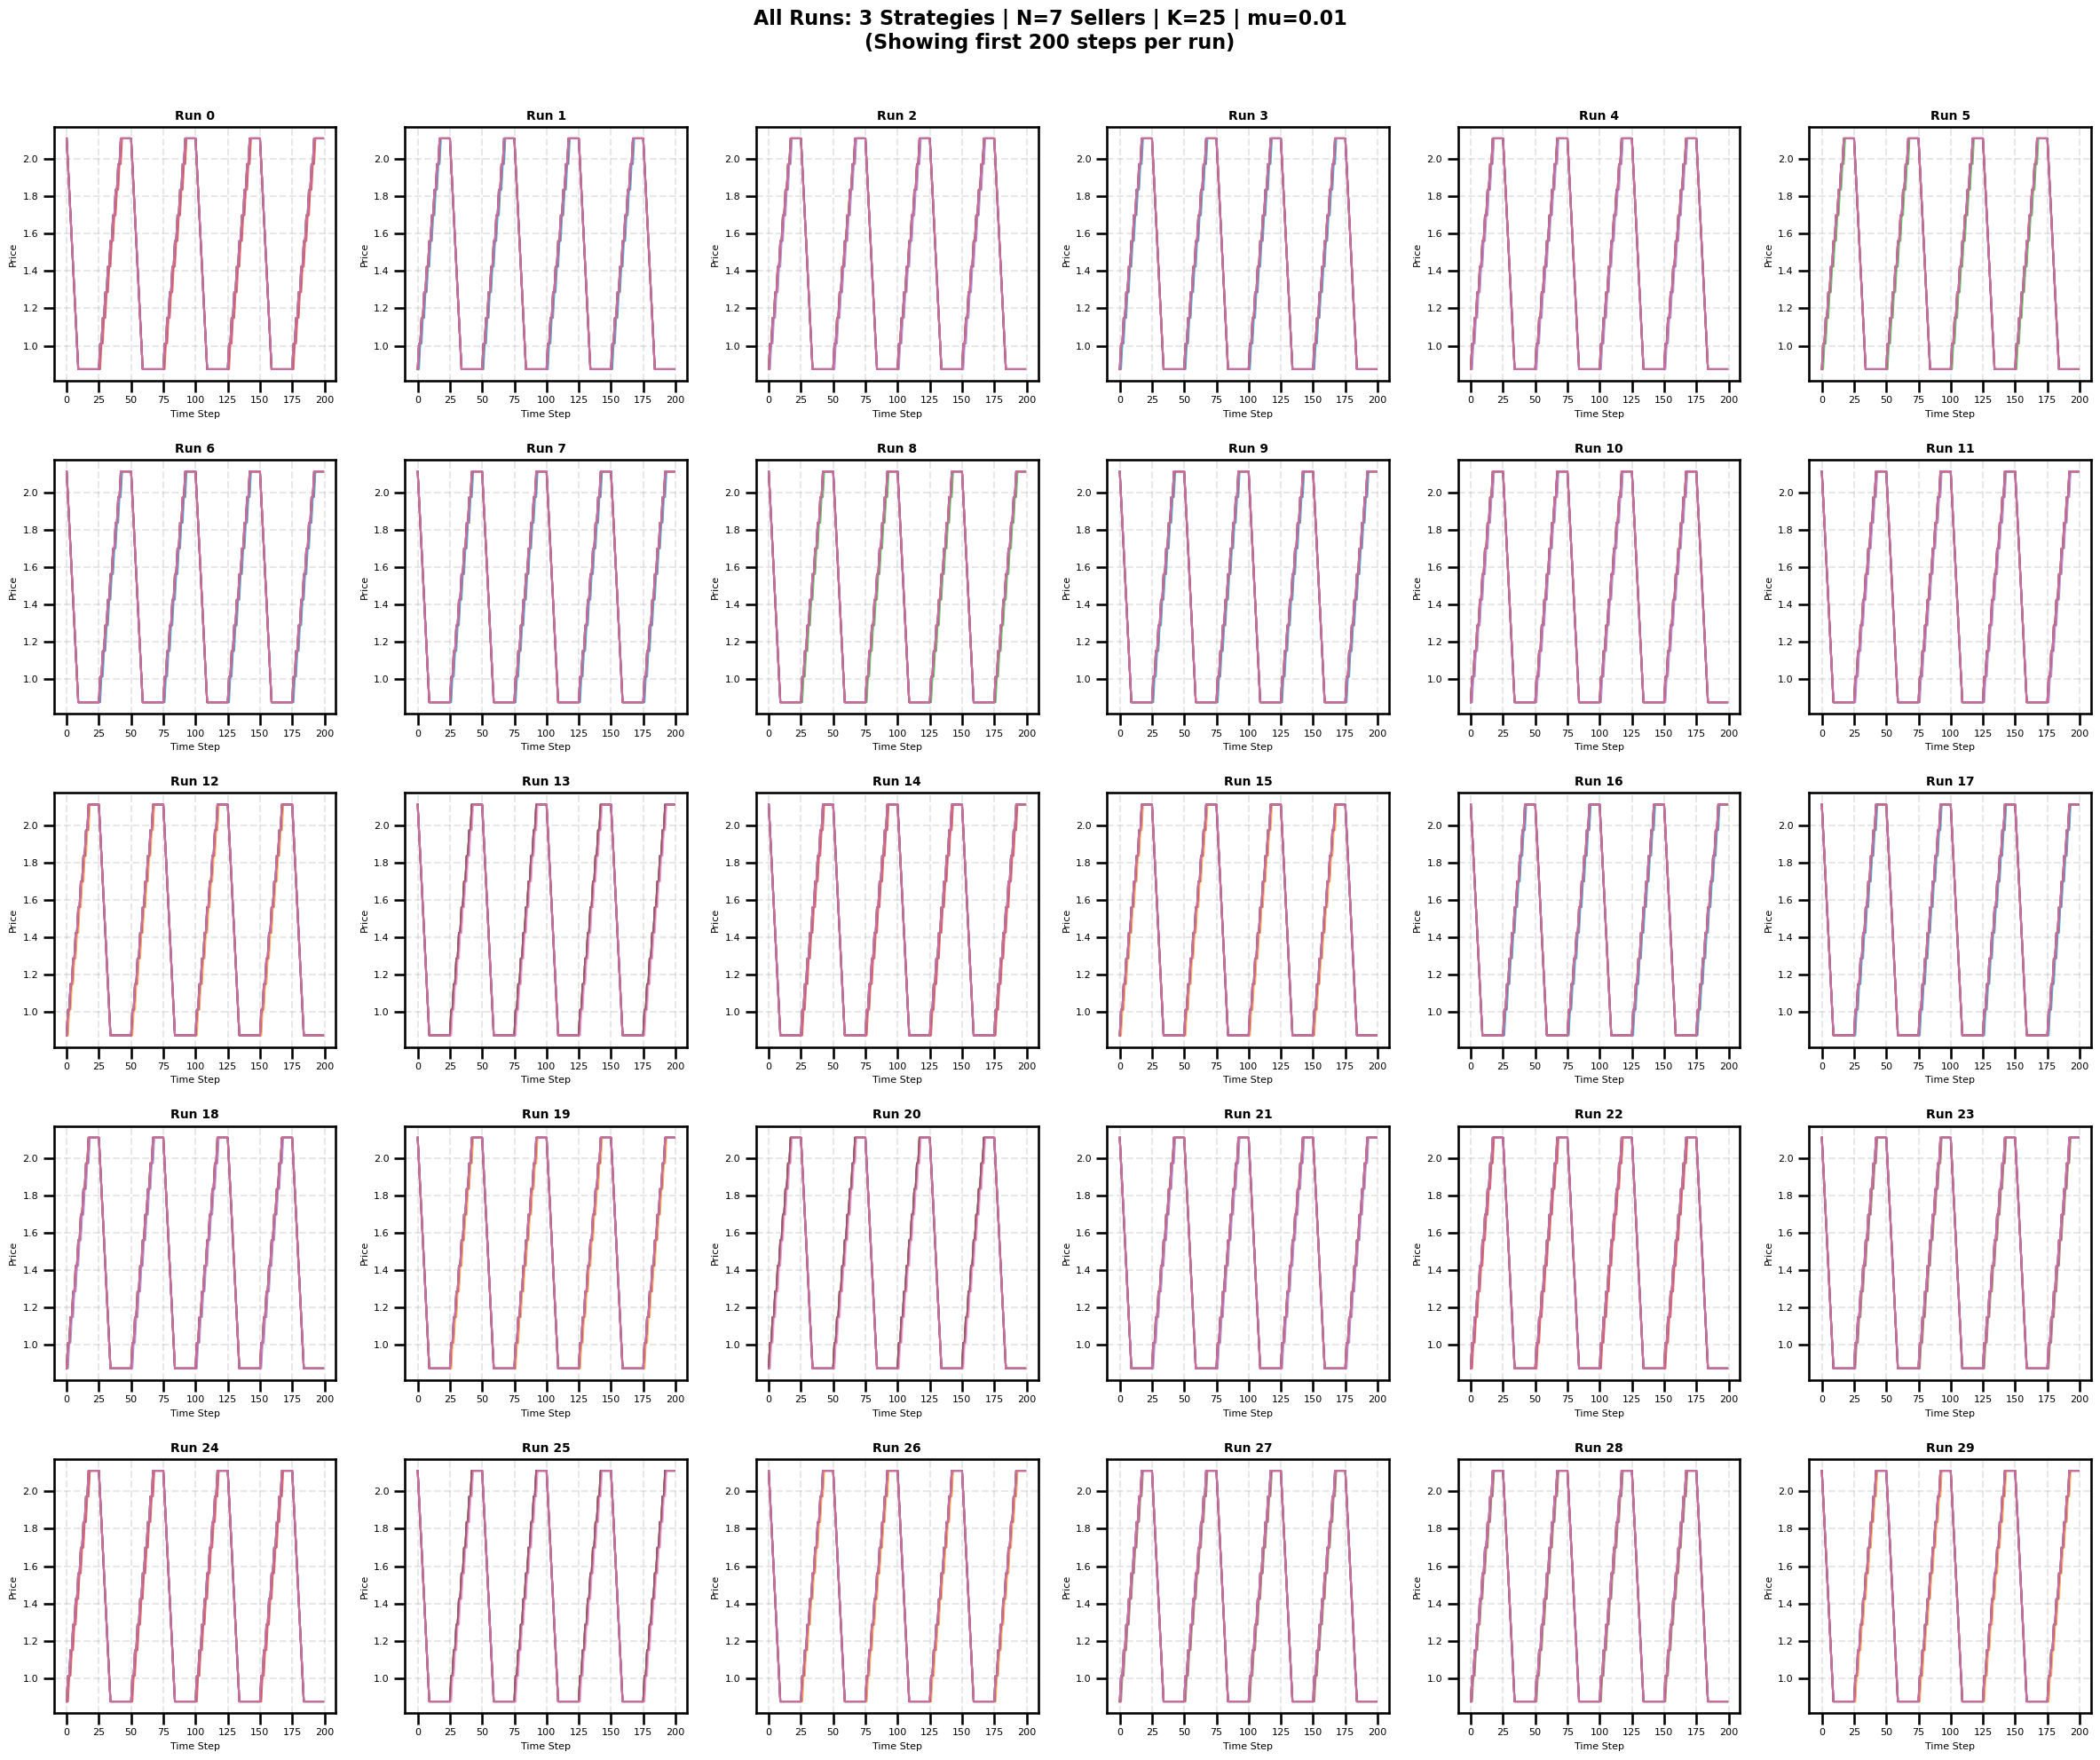

In [6]:
# Example 3: 3 strategies, N=7, K=25, mu=0.1
plot_all_runs_grid(strats=3, N=7, k=25, mu=0.01, max_steps=200)

Found 30 runs in scan_4strats_mu0.19_k30/N_7


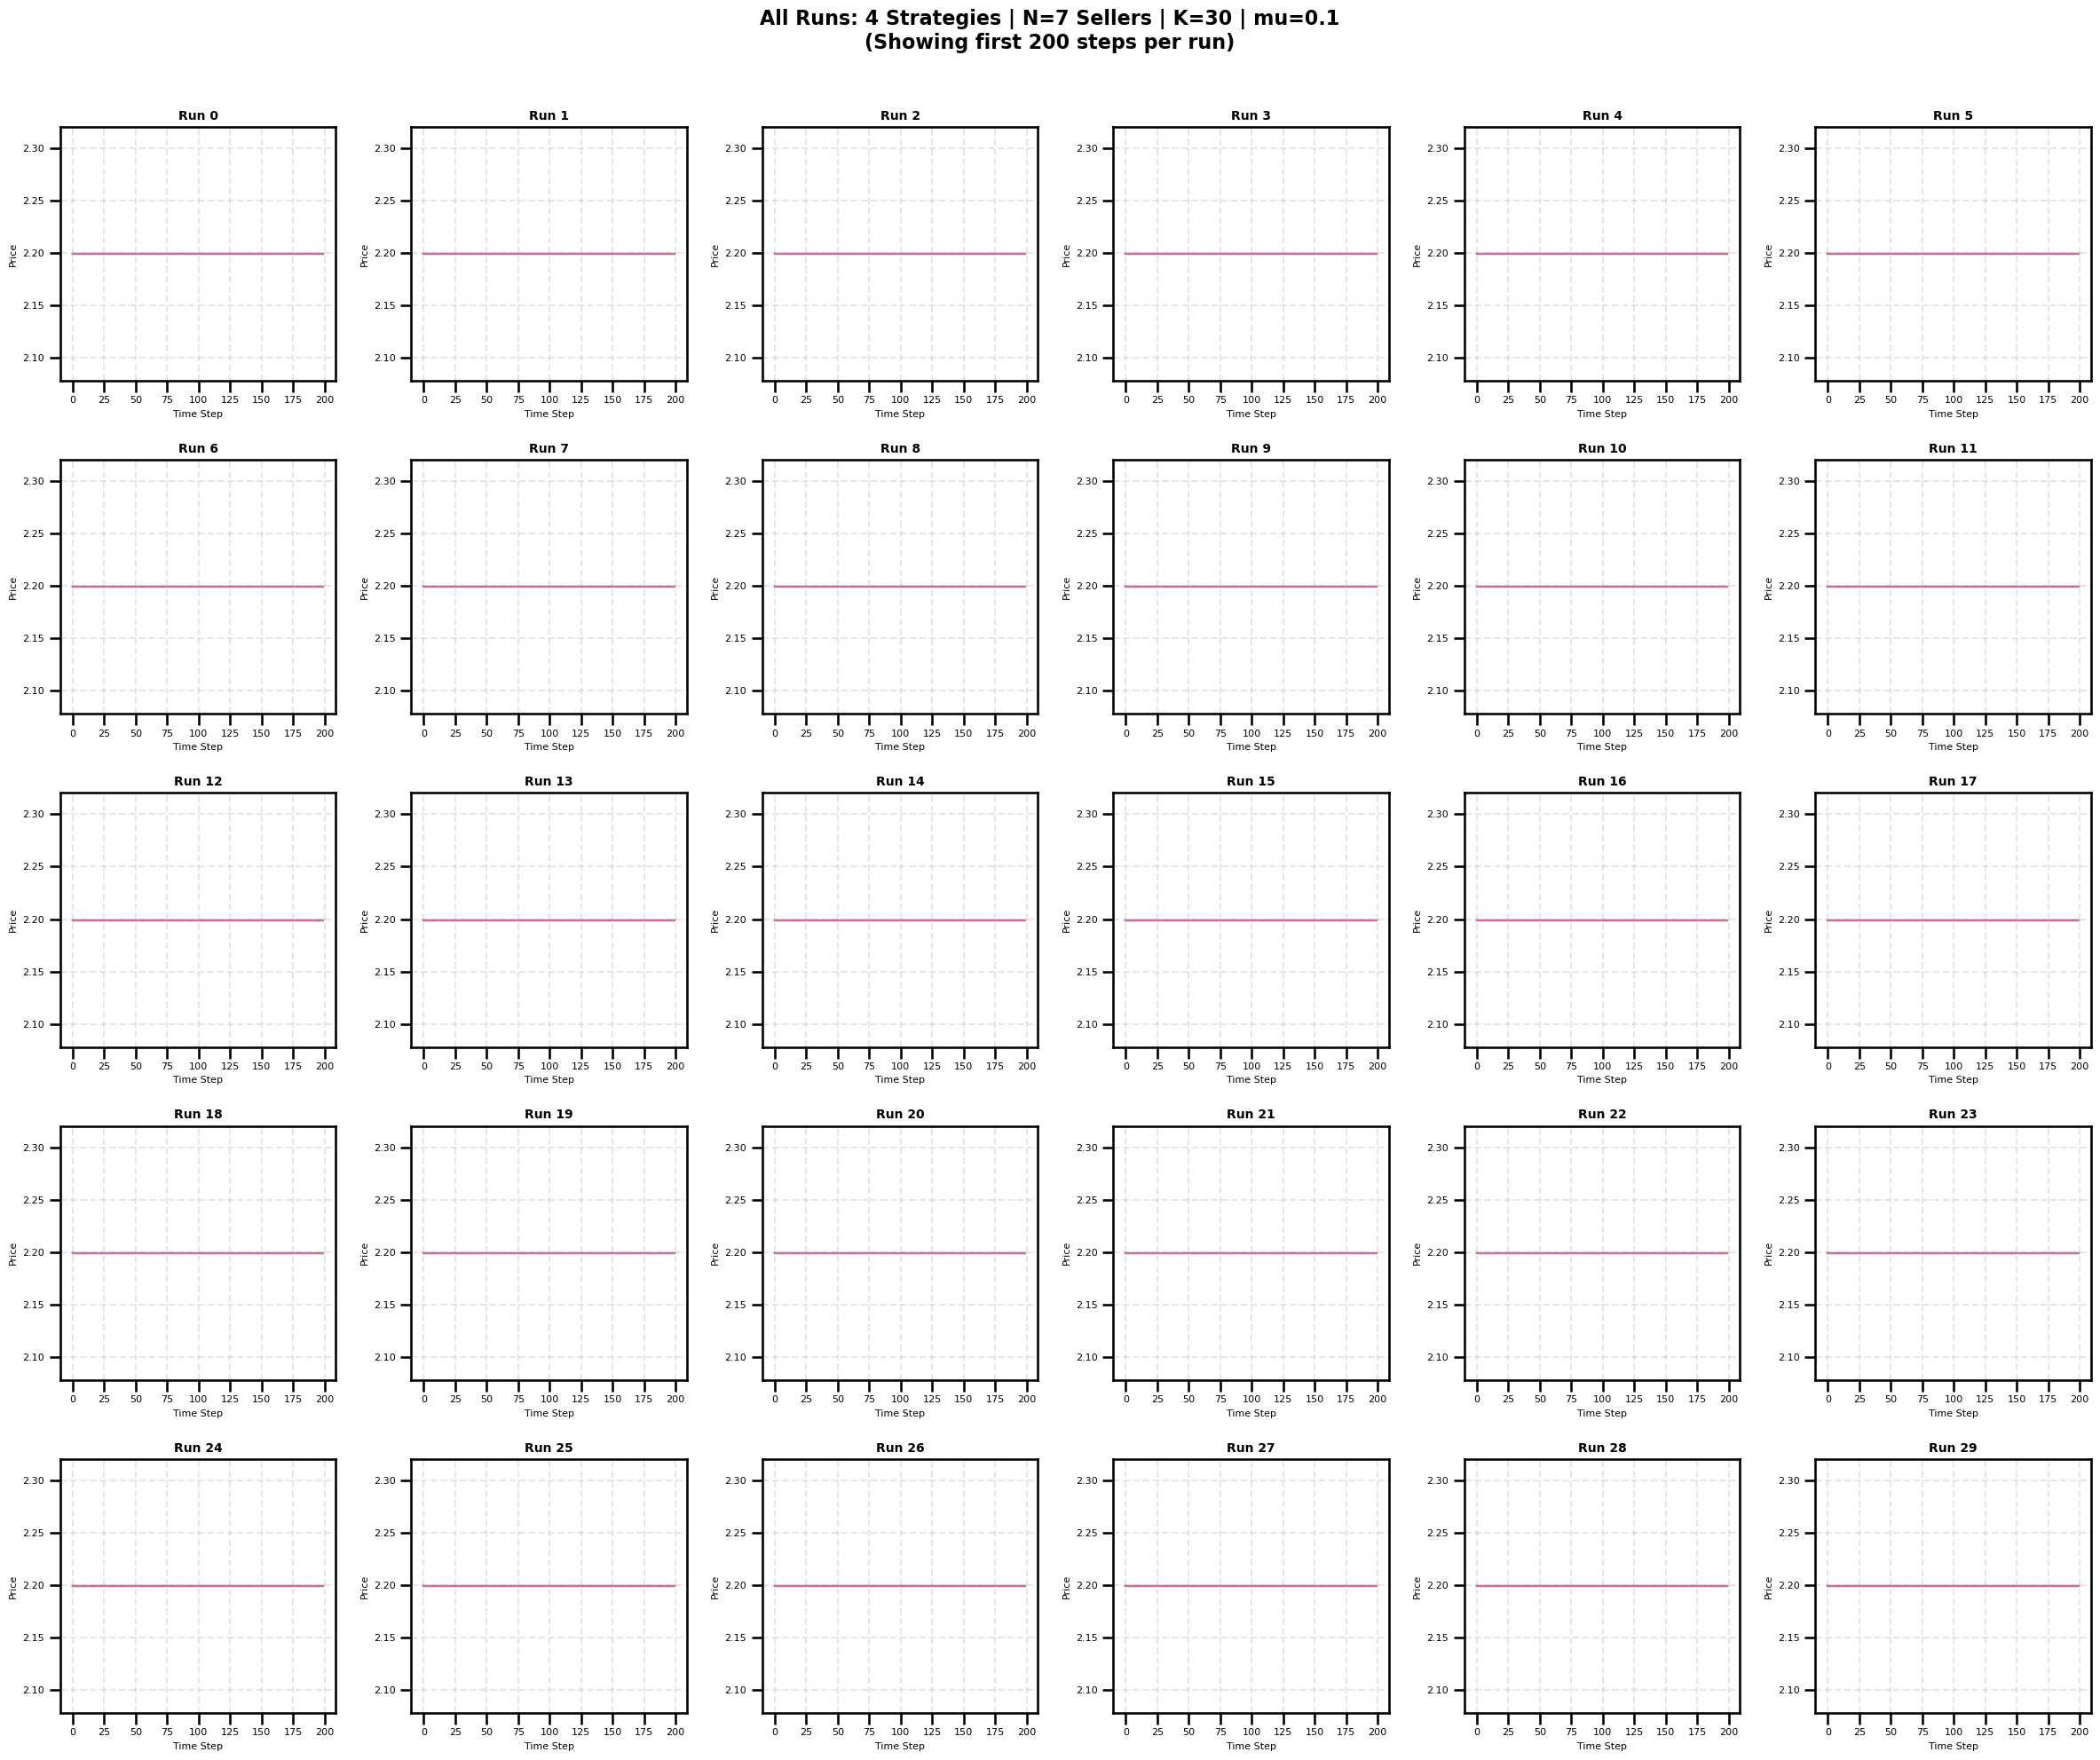

In [7]:
# Example 4: 4 strategies, N=7, K=30, mu=0.01
plot_all_runs_grid(strats=4, N=7, k=30, mu=0.1, max_steps=200)

Found 30 runs in scan_4strats_mu0.22_k30/N_10


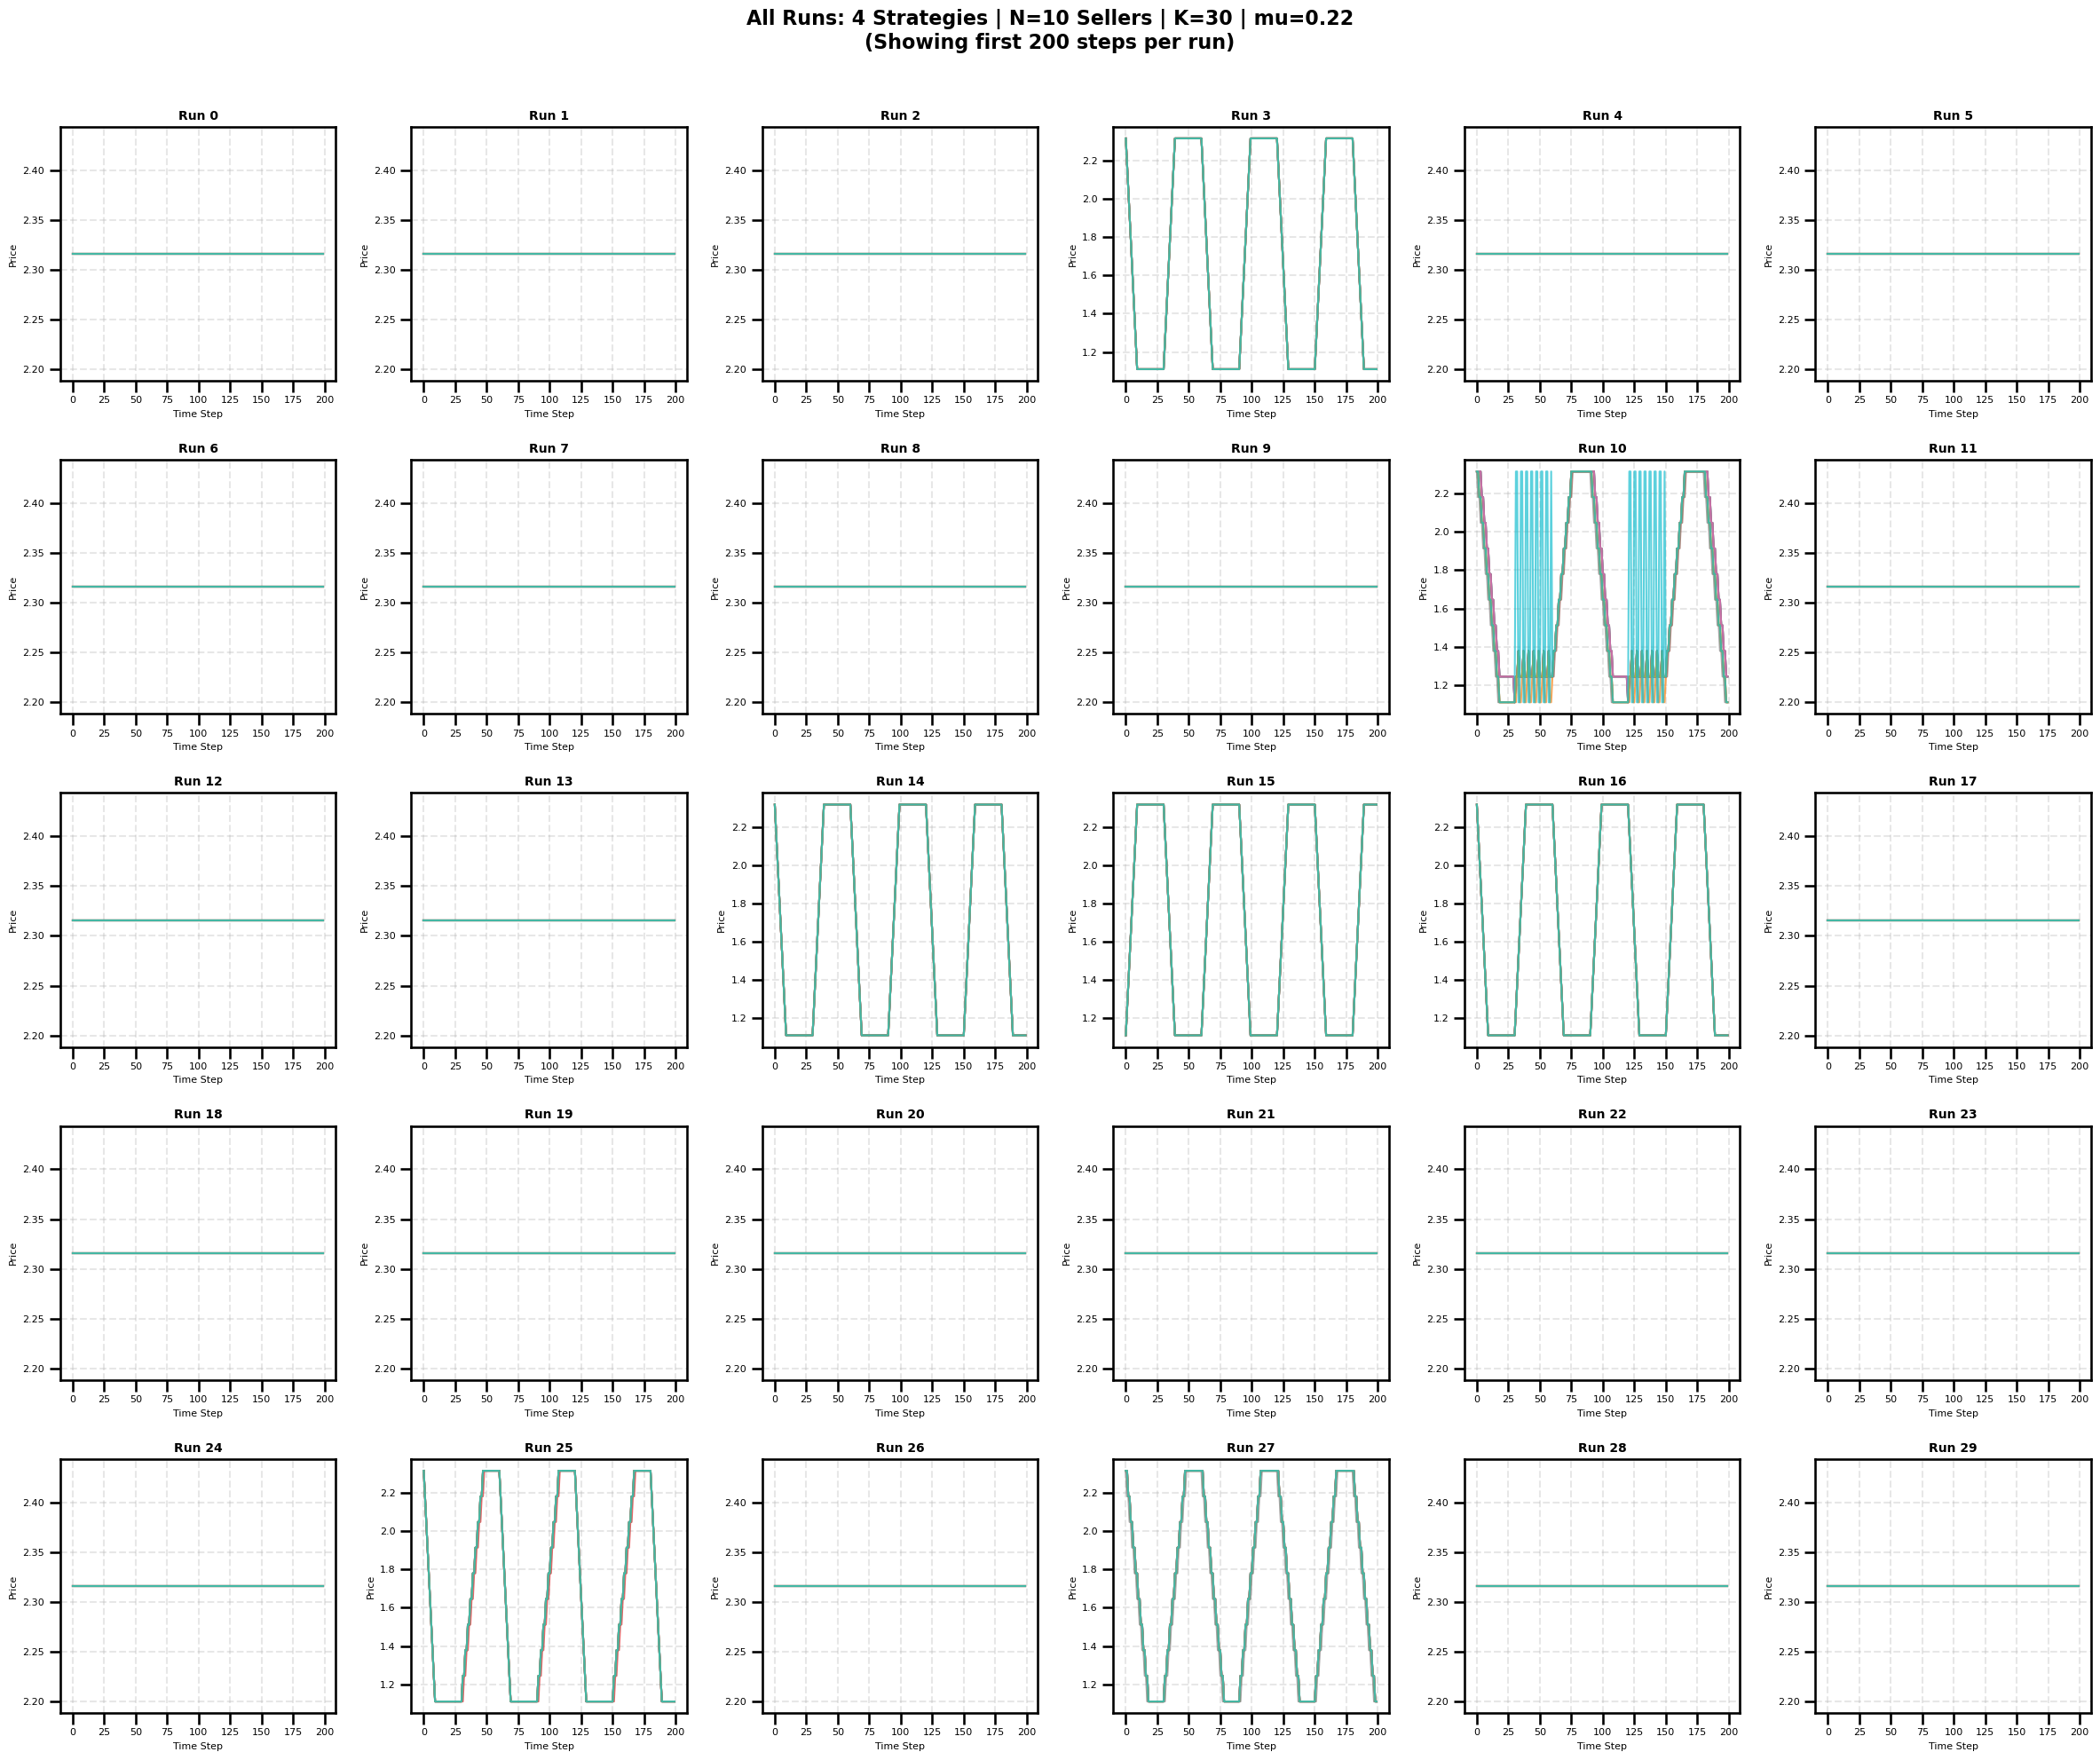

In [8]:
plot_all_runs_grid(strats=4, N=10, k=30, mu=0.22, max_steps=200)

Found 30 runs in scan_4strats_mu0.04_k30/N_3


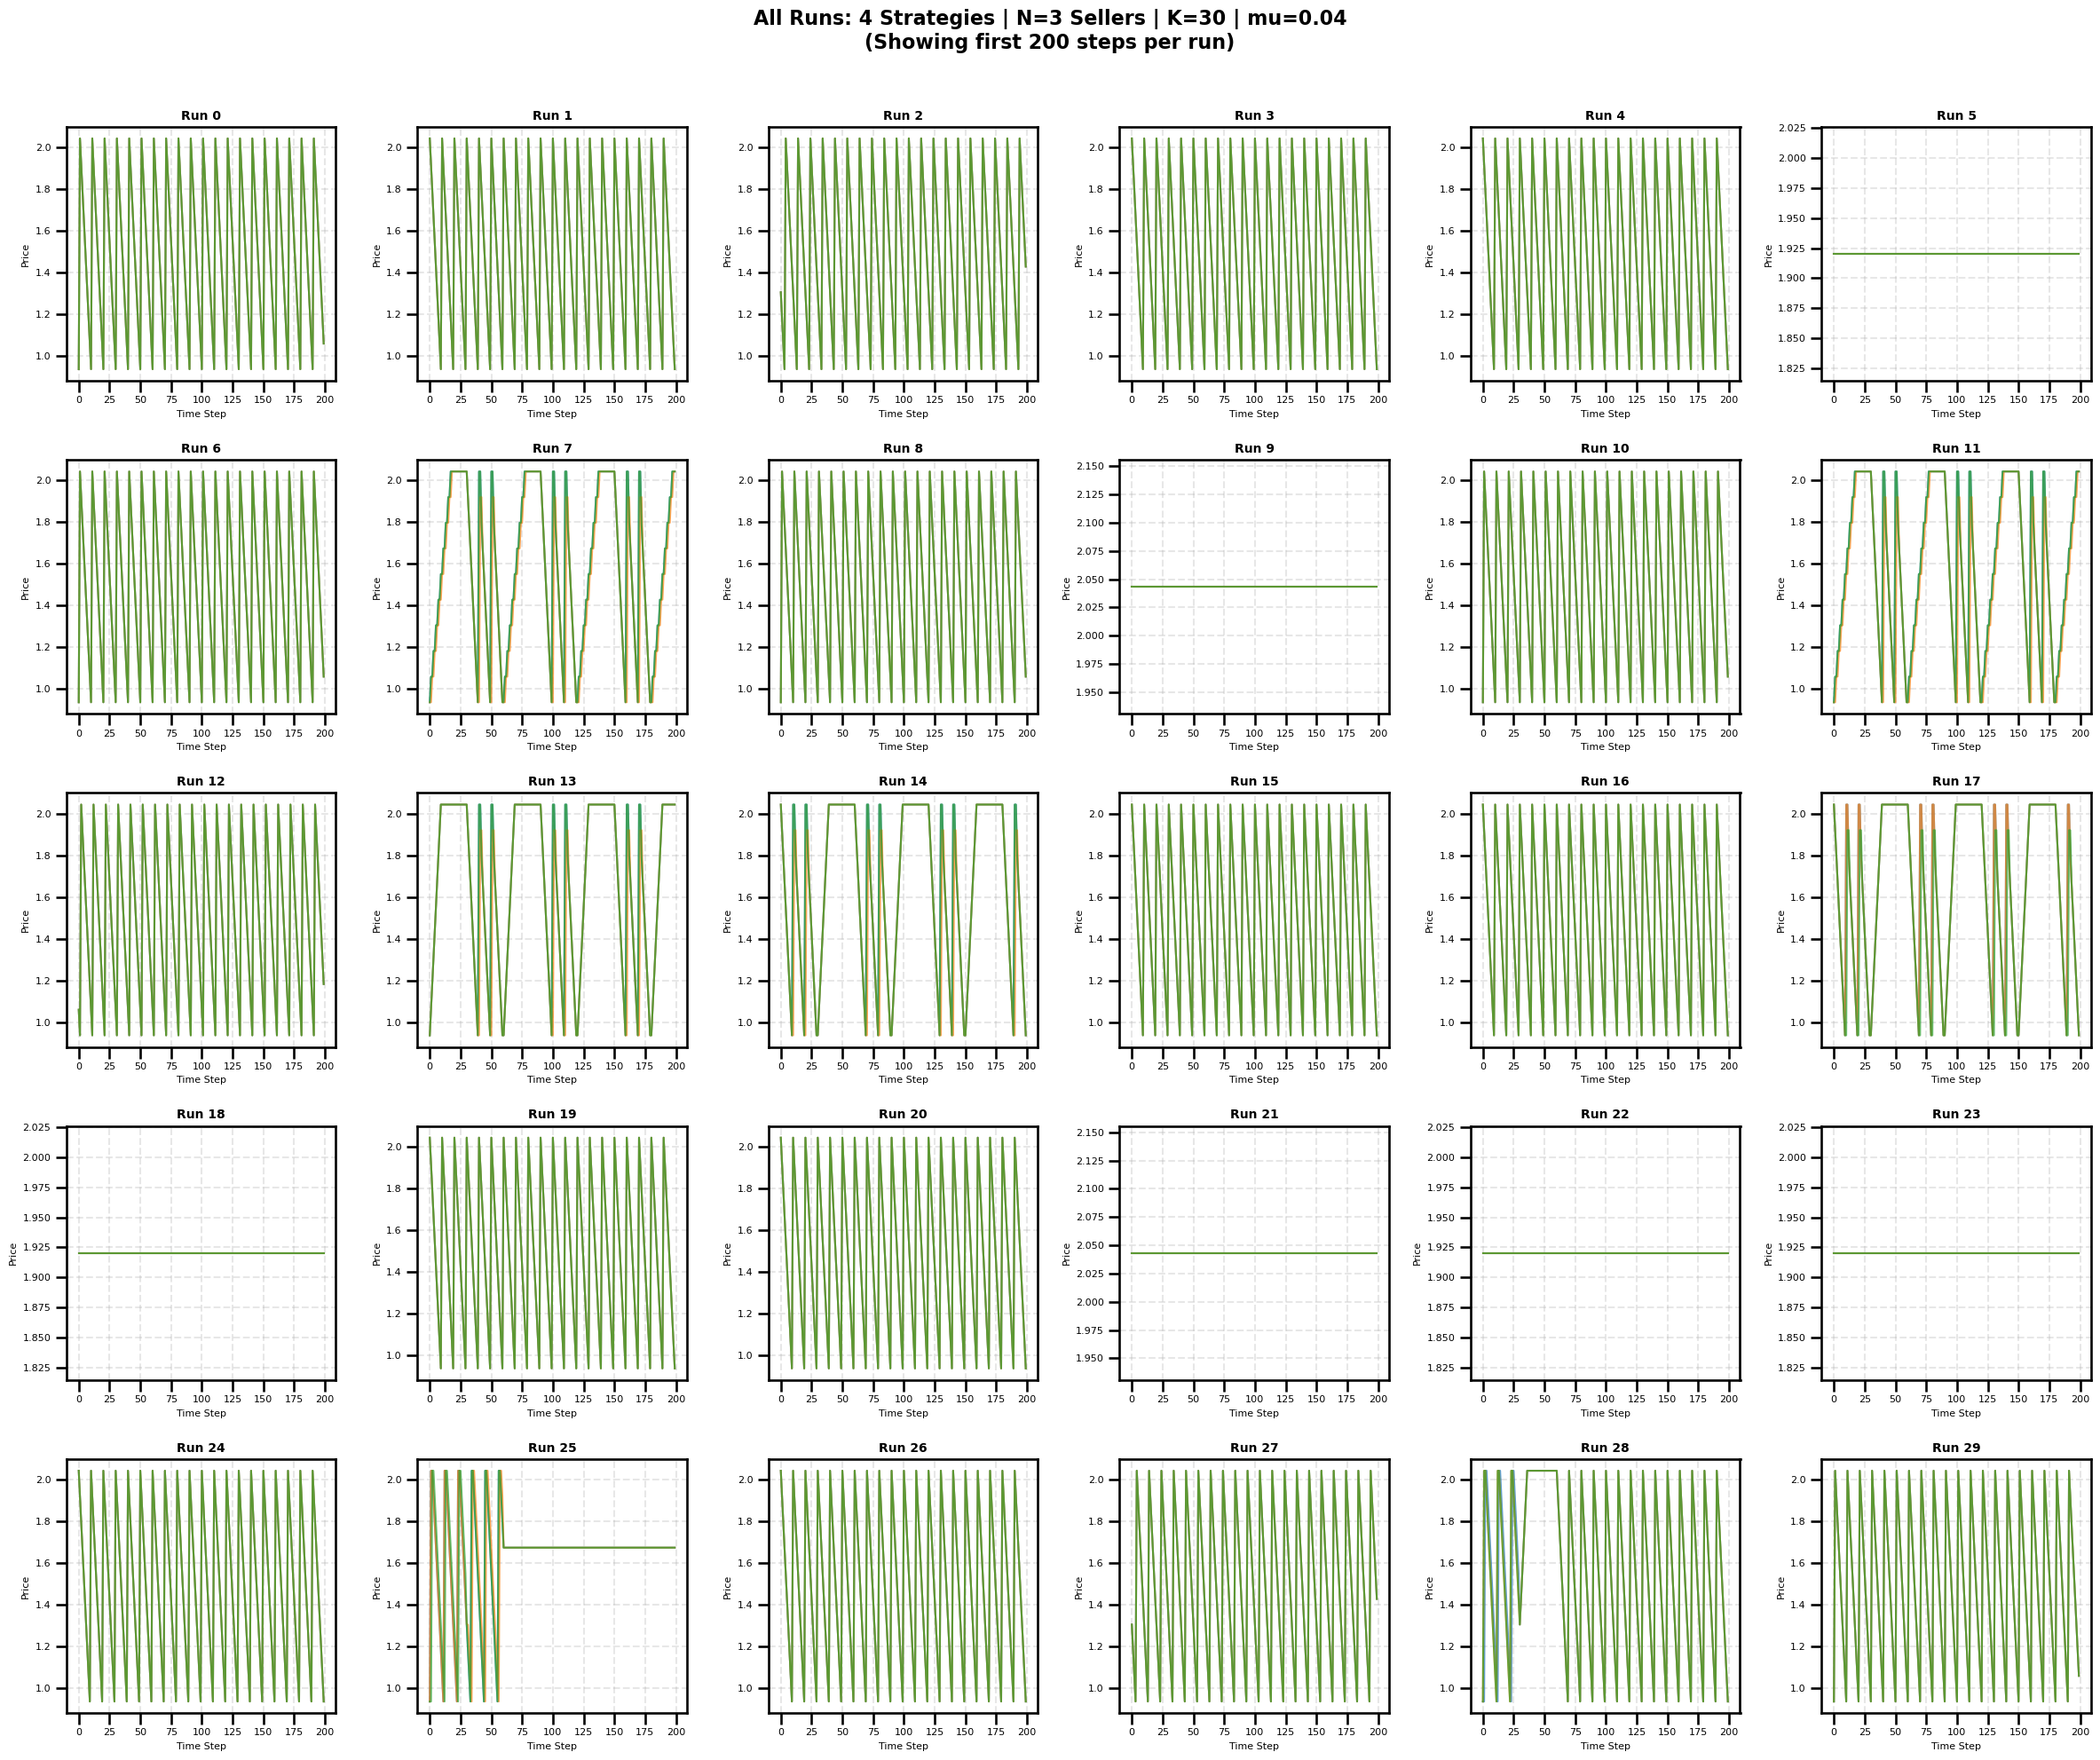

In [9]:
plot_all_runs_grid(strats=4, N=3, k=30, mu=0.04, max_steps=200)

Found 30 runs in scan_4strats_mu0.01_k25/N_5


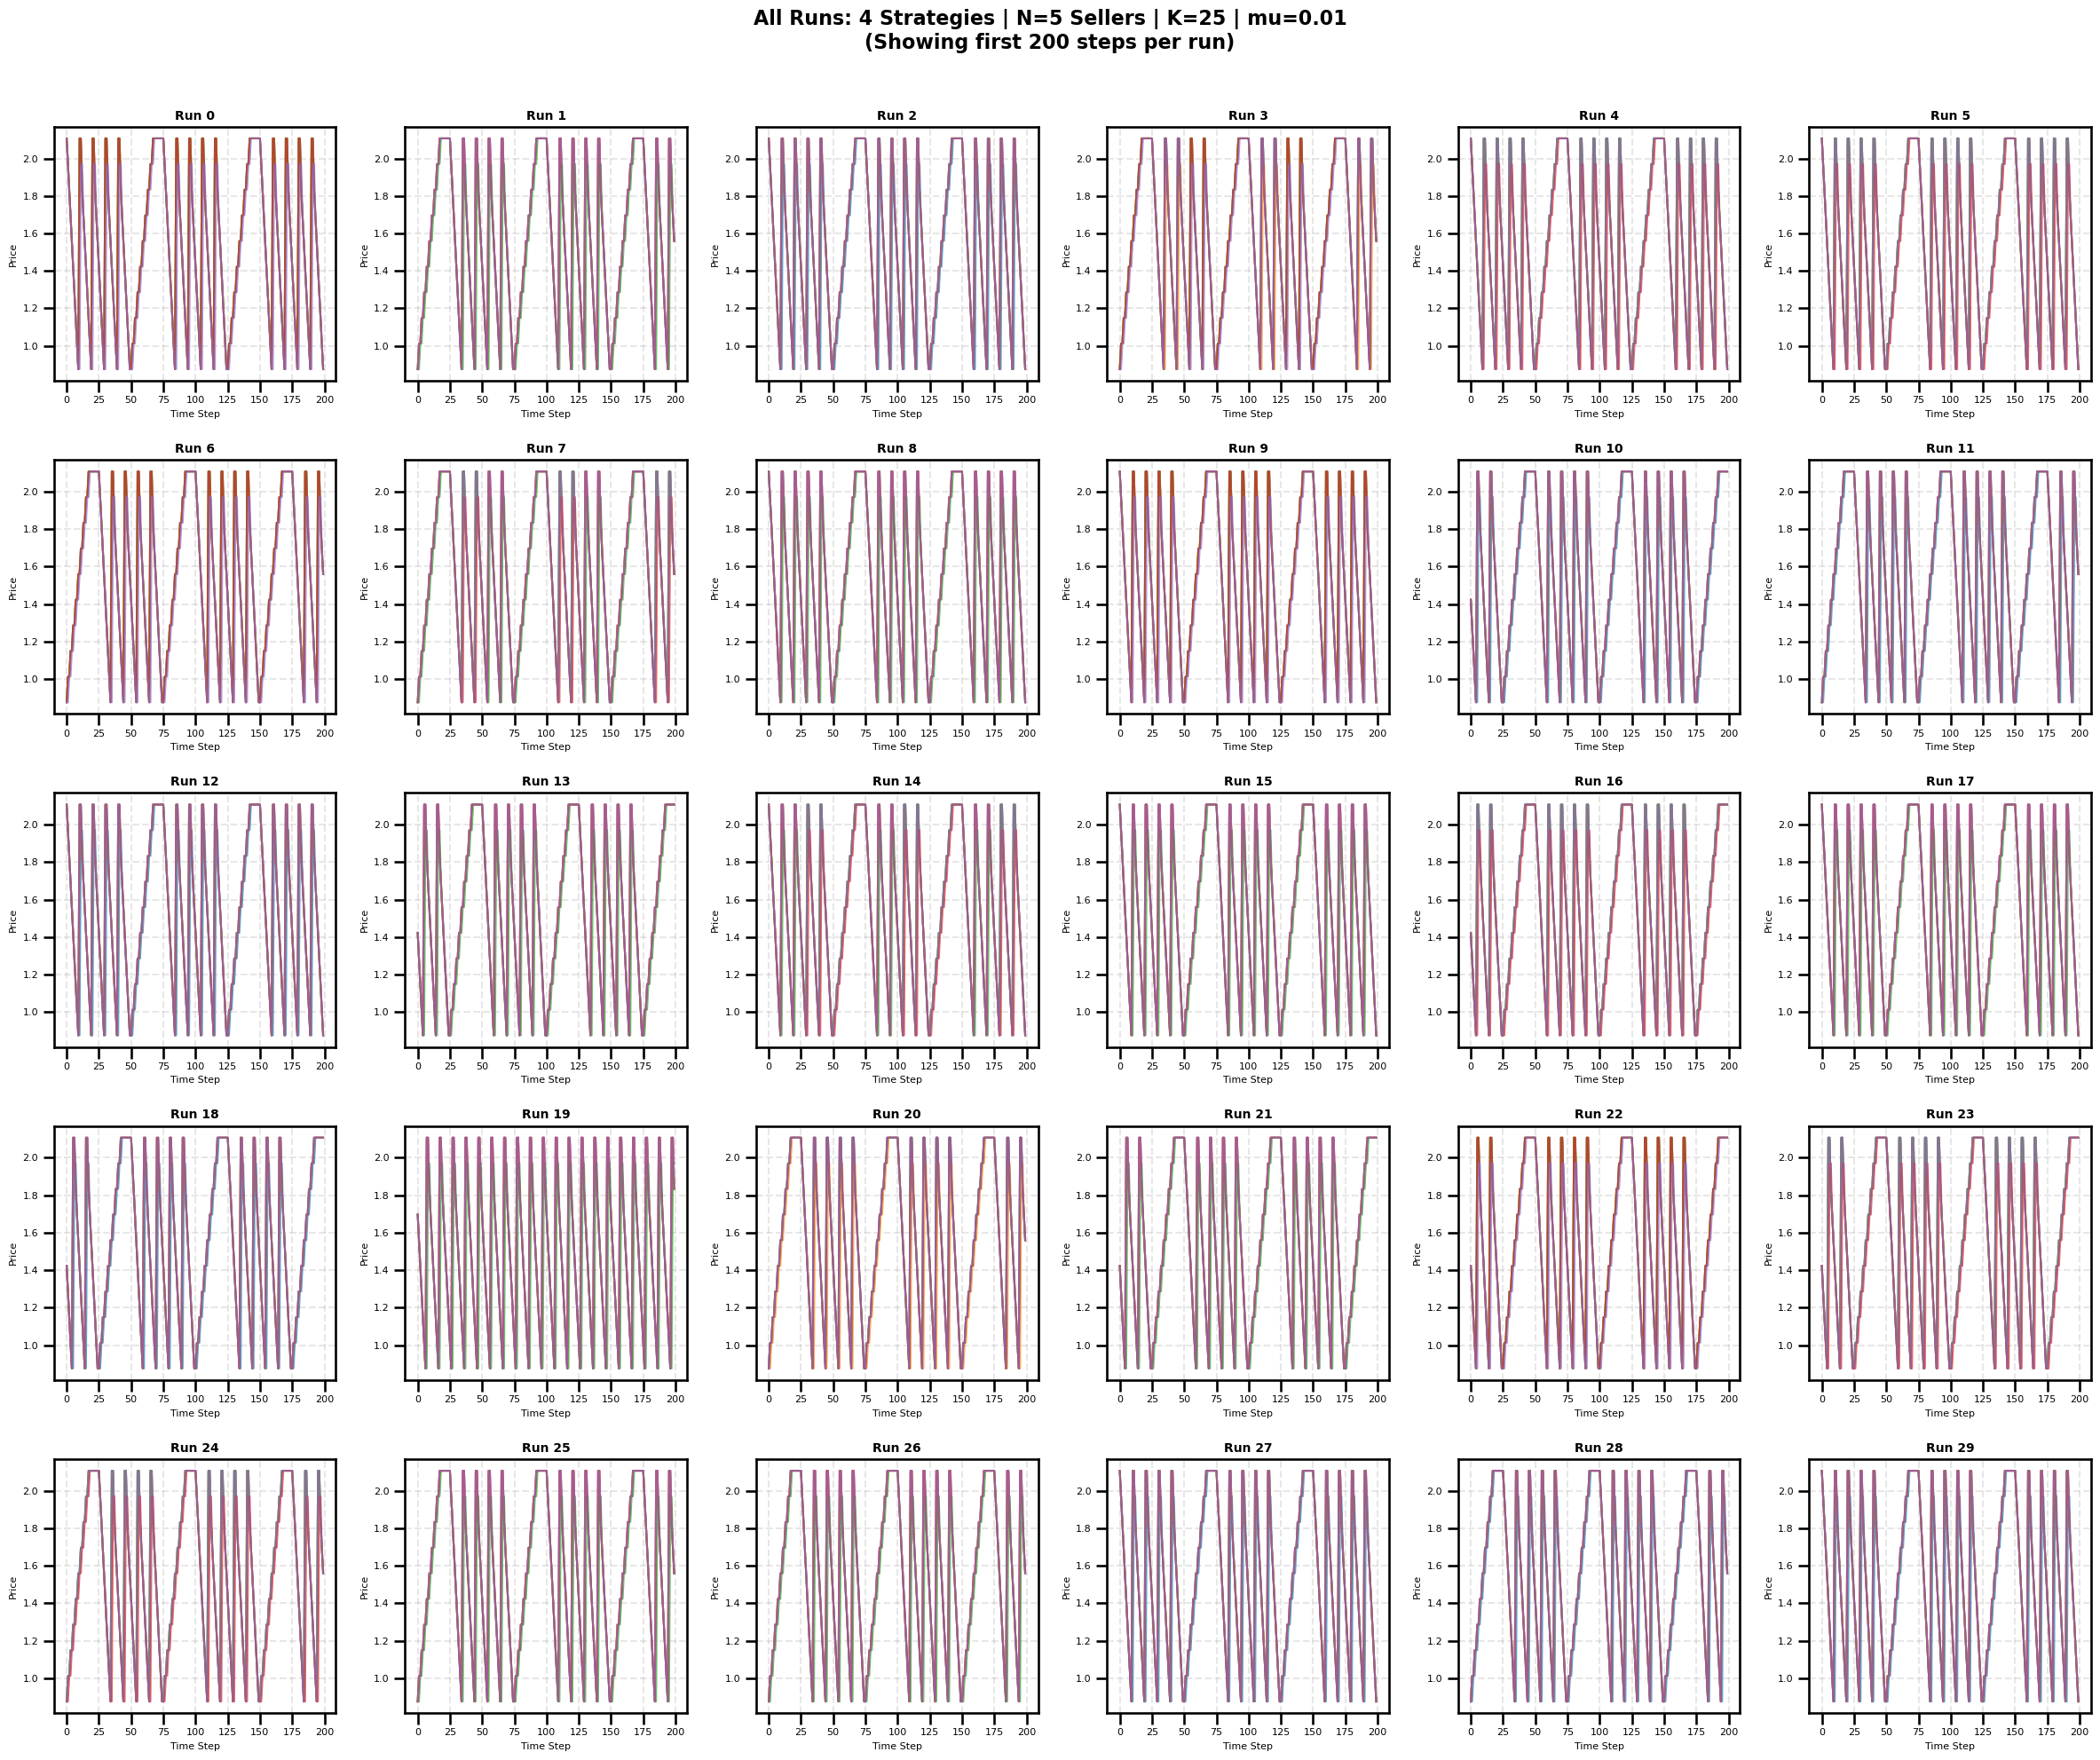

In [10]:
plot_all_runs_grid(strats=4, N=5, k=25, mu=0.01, max_steps=200)

Found 30 runs in scan_3strats_mu0.01_k35/N_5


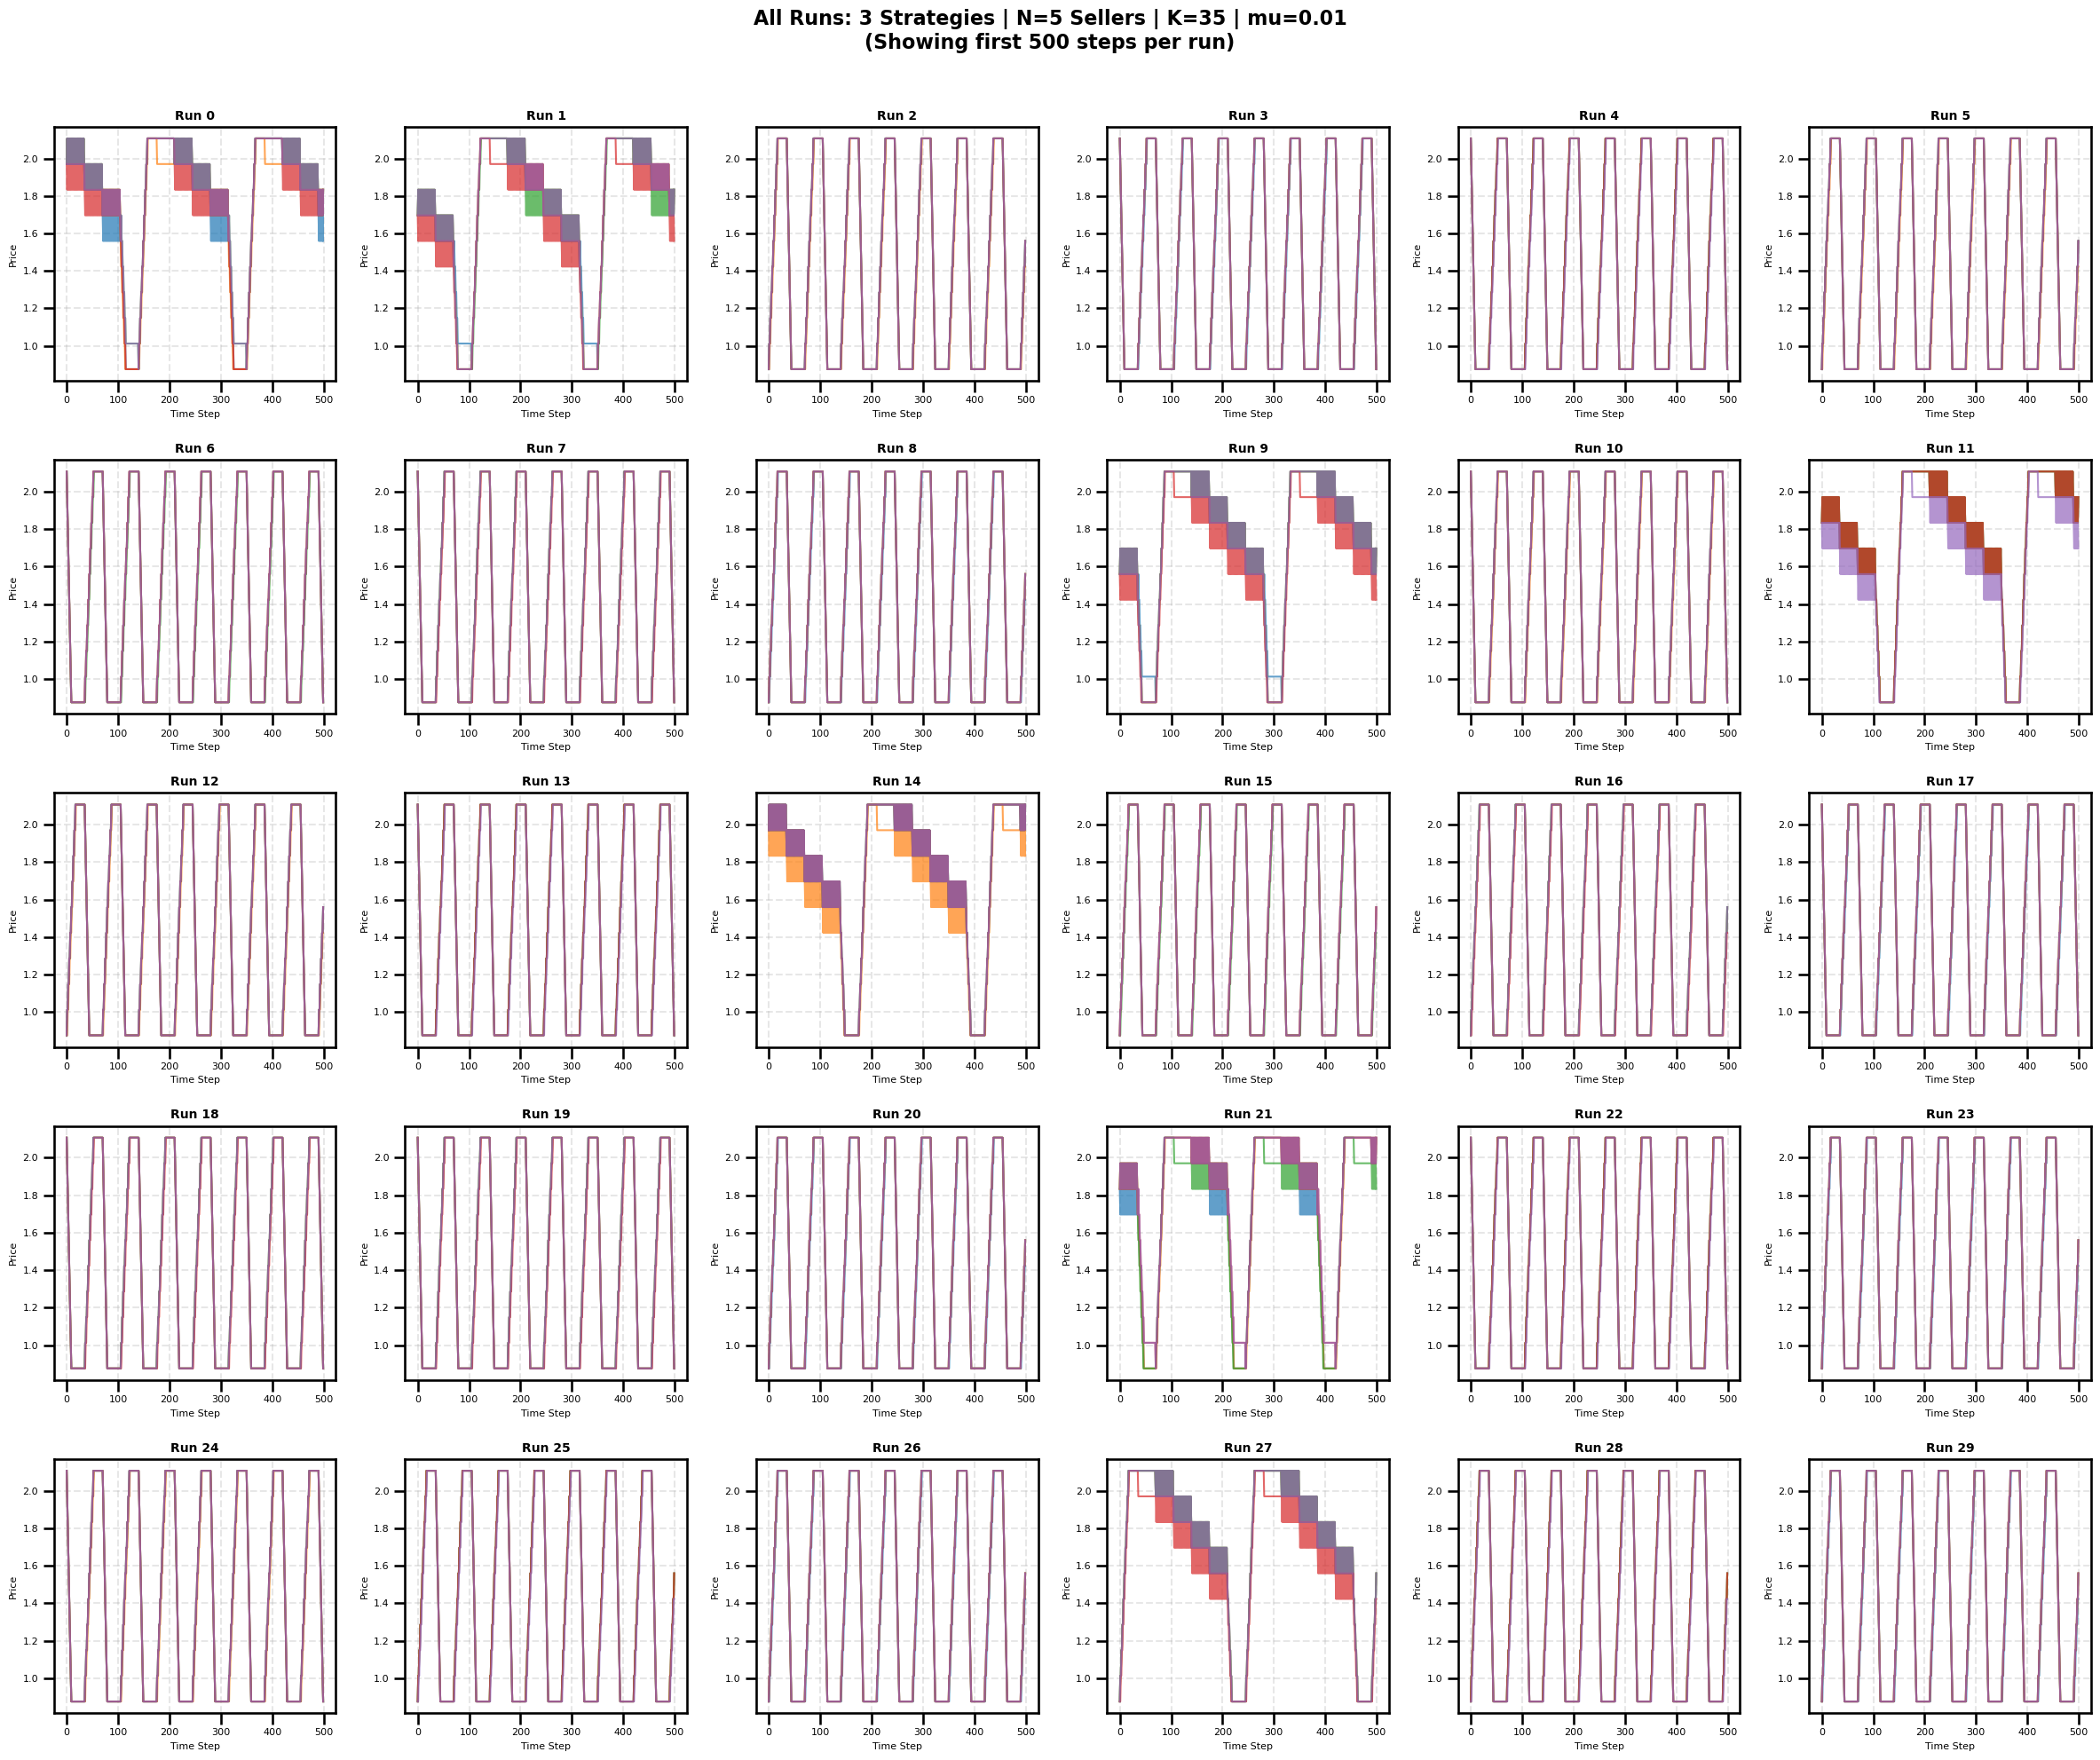

In [11]:
plot_all_runs_grid(strats=3, N=5, k=35, mu=0.01, max_steps=500)

## Interactive: Choose Your Own Configuration

Modify the parameters below to explore different configurations:

Found 30 runs in scan_3strats_mu0.01_k25/N_3


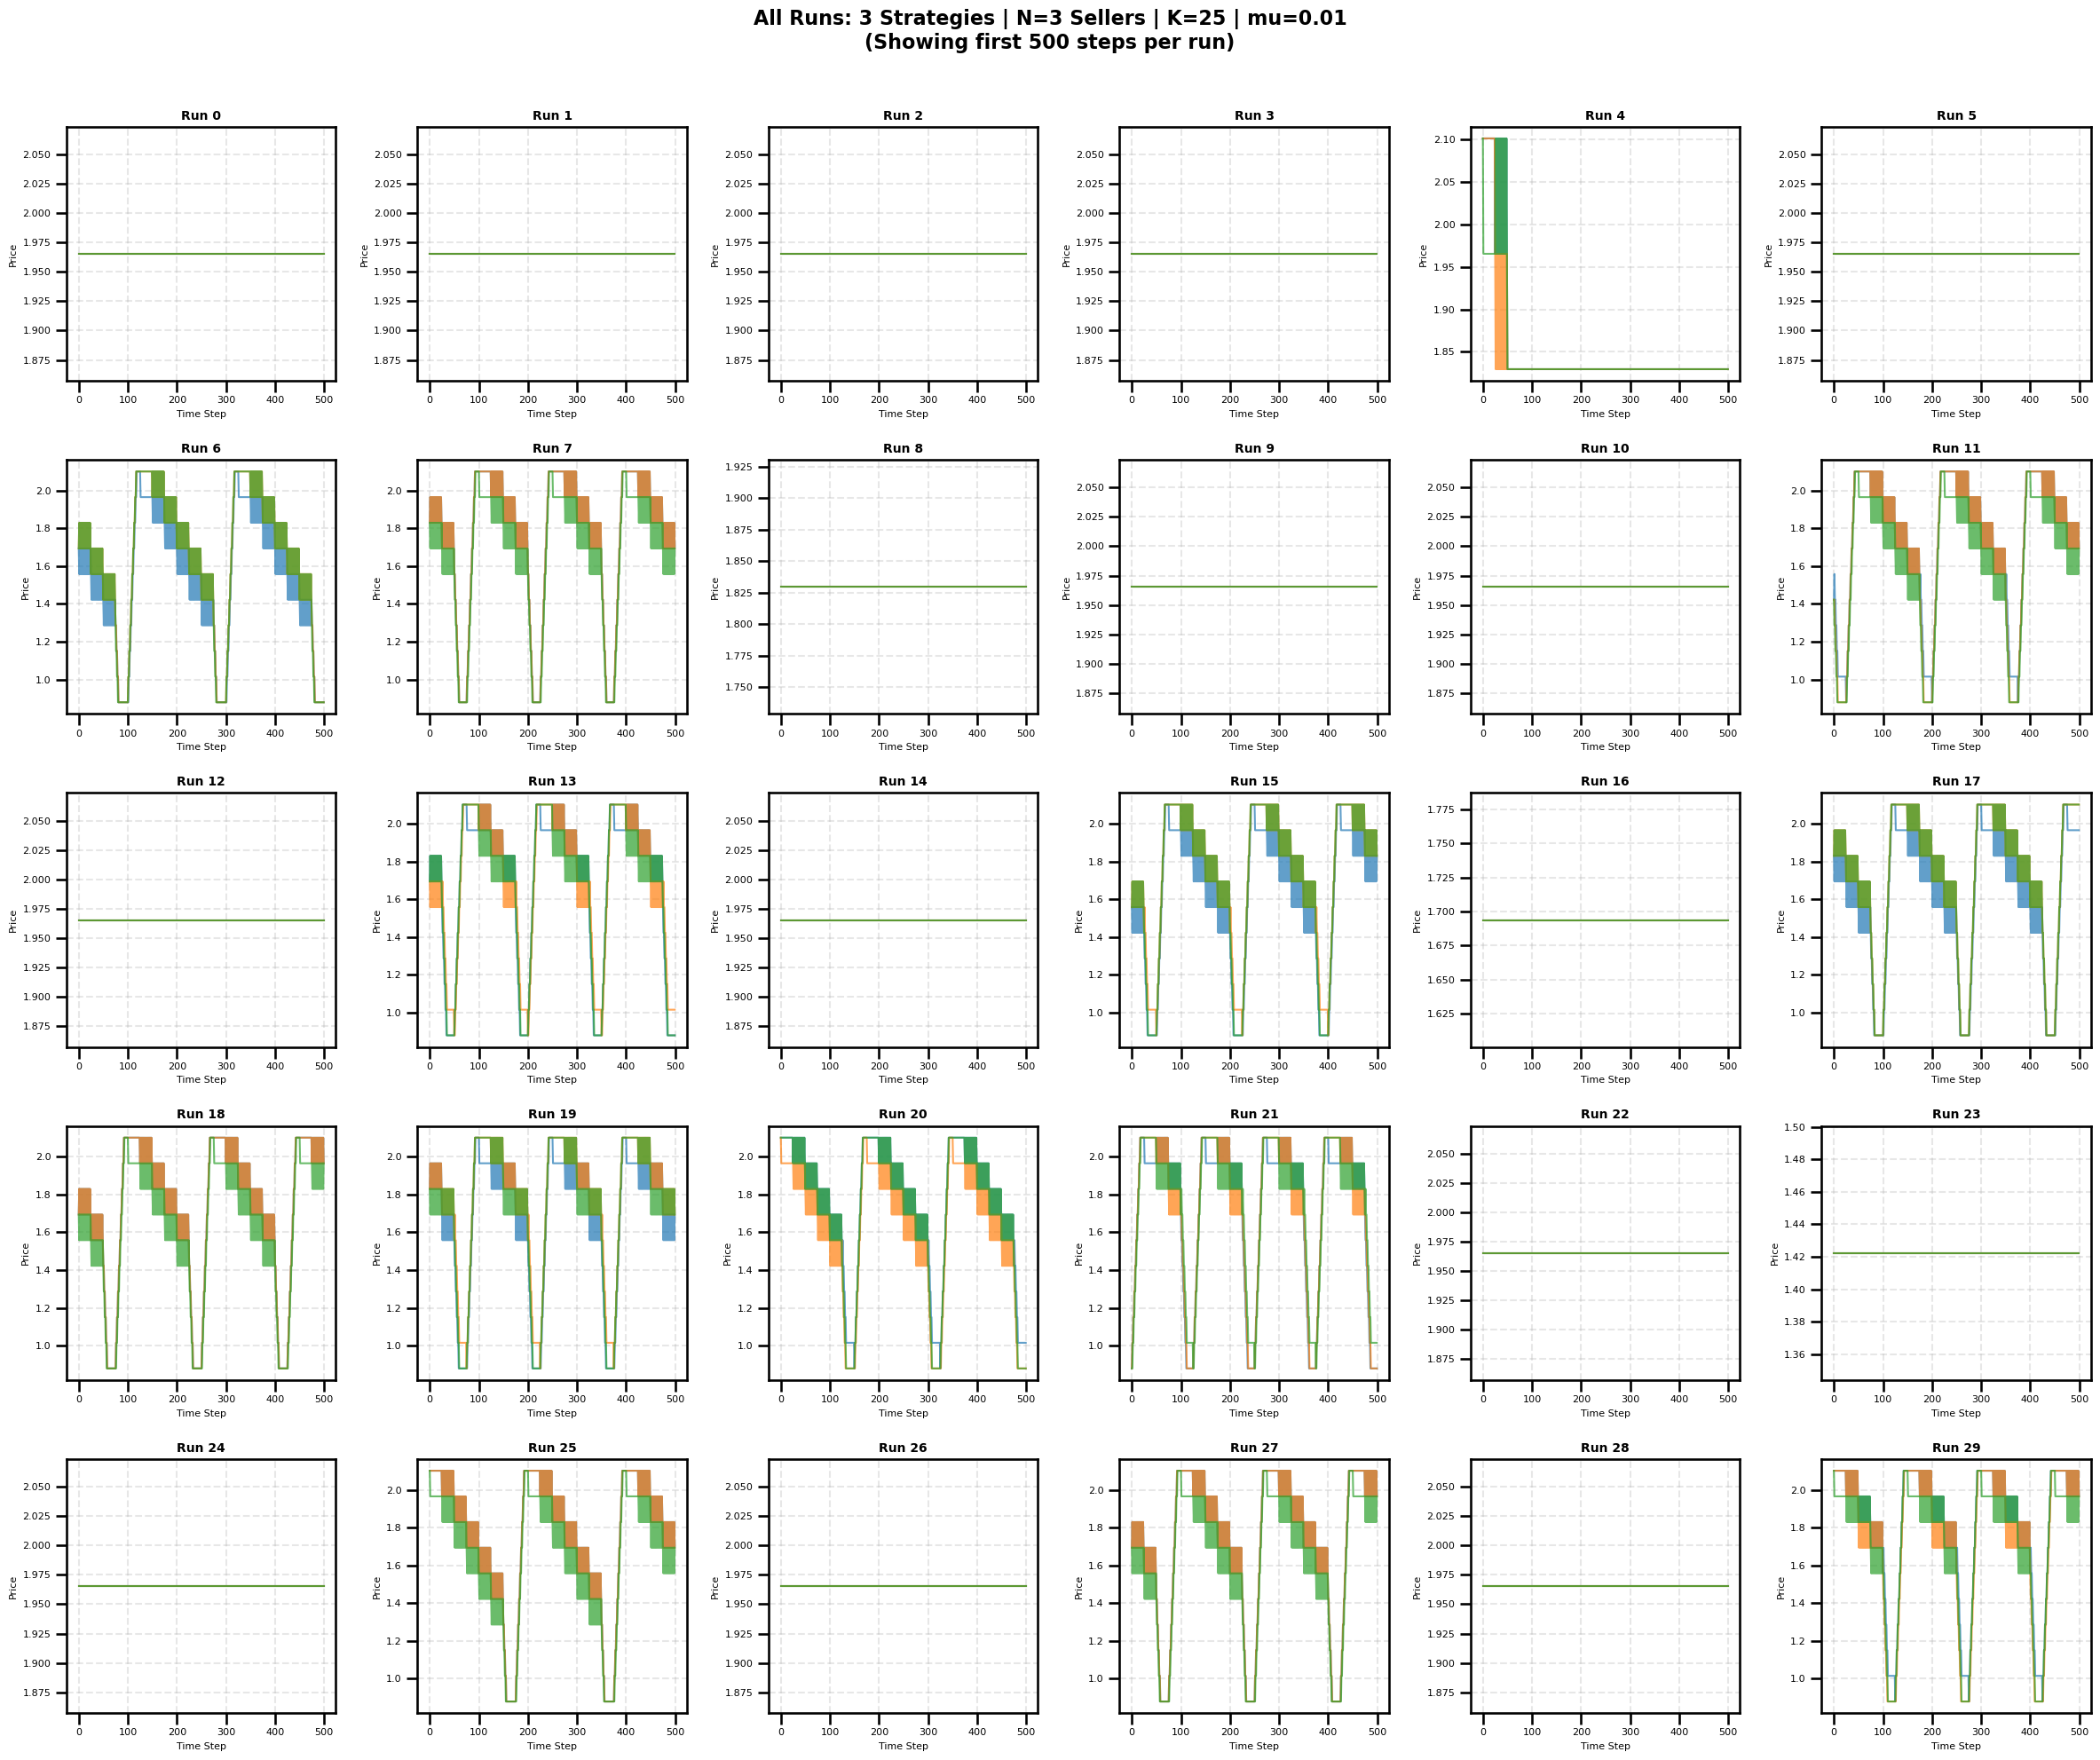

In [12]:
# === CUSTOMIZE HERE ===
strats = 3      # 3 or 4
N = 3           # Number of sellers
k = 25          # K parameter
mu = 0.01       # competitiveness
max_steps = 500 # Number of steps to show

plot_all_runs_grid(strats=strats, N=N, k=k, mu=mu, max_steps=max_steps)